# Análisis de Detección de Puntos de Cambio


## 1. Importar Librerías Requeridas

In [1]:
import numpy as np
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from tabulate import tabulate
from matplotlib.ticker import MultipleLocator

from Algoritmo_Gaussiano.cpd import CPD
from Algoritmo_Empiricas.Empirical_CPD import EmpiricalCPD
from Series_Prueba.periodical_data import generar_series_pc, next_prob, serie_pc
from Series_Prueba.ARIMA import arima_serie
from Utils.detection import detect
from Utils.metrics_sup import metrics
from Series_Prueba.experimentos import samples_200_arma, samples_200_sin, ar2_noise
import roerich
from roerich.change_point import ChangePointDetectionClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from Algoritmo_KLIEP.kliep_cpd import KLIEP_CPD
from Algoritmo_klcpd.klcpd import detect_changepoints as klcpd_detect
from Utils.tools import best_params_sh

## 2. Funciones de Comparación Estadística

In [2]:
def wilcoxon_metrica(arr_1,
                     arr_2,
                     minimizar=False,
                     alpha=0.05):
    """
    Realiza un test de Wilcoxon pareado entre dos arreglos.

    Parámetros
    ----------
    arr_1 : array-like
        Resultados del método 1.

    arr_2 : array-like
        Resultados del método 2.

    minimizar : bool, default=False
        - False -> métricas donde mayor es mejor.
        - True  -> métricas donde menor es mejor.

    alpha : float, default=0.05
        Nivel de significancia.

    Retorna
    -------
    dict
        Resultados estadísticos del test.
    """

    x = np.asarray(arr_1, dtype=float)
    y = np.asarray(arr_2, dtype=float)

    mask = ~(np.isnan(x) | np.isnan(y))
    x = x[mask]
    y = y[mask]

    stat, p_value = wilcoxon(x, y)

    media_x = np.mean(x)
    media_y = np.mean(y)

    diferencia = p_value < alpha

    if diferencia:

        if minimizar:
            mejor = "Método 1" if media_x < media_y else "Método 2"
        else:
            mejor = "Método 1" if media_x > media_y else "Método 2"

    else:
        mejor = "Sin diferencia"

    return {
        "media_1": media_x,
        "media_2": media_y,
        "estadistico": stat,
        "p_value": p_value,
        "diferencia": diferencia,
        "mejor": mejor
    }

In [3]:
def comparar_metricas(metricas_metodo_1,
                      metricas_metodo_2,
                      nombre_metodo_1="Gaussiano",
                      nombre_metodo_2="Empírico",
                      alpha=0.05,
                      mostrar_tabla=True):
    """
    Compara múltiples métricas usando Wilcoxon pareado.

    Orden esperado:
    ----------------
    [0] Error Medio de Localización
    [1] Precisión
    [2] Exactitud
    [3] Medida F1
    """

    nombres_metricas = [
        "Error Medio de Localización",
        "Precisión",
        "Exactitud",
        "Medida F1"
    ]

    criterios = [
        True,
        False,
        False,
        False
    ]

    resultados = []

    for nombre, minimizar, arr1, arr2 in zip(
        nombres_metricas,
        criterios,
        metricas_metodo_1,
        metricas_metodo_2
    ):

        r = wilcoxon_metrica(
            arr1,
            arr2,
            minimizar=minimizar,
            alpha=alpha
        )

        if r["mejor"] == "Método 1":
            mejor = nombre_metodo_1
        elif r["mejor"] == "Método 2":
            mejor = nombre_metodo_2
        else:
            mejor = "Sin diferencia"

        resultados.append({
            "Métrica": nombre,
            f"Promedio {nombre_metodo_1}": r["media_1"],
            f"Promedio {nombre_metodo_2}": r["media_2"],
            "p-valor": r["p_value"],
            "Diferencia estadística": (
                "Sí" if r["diferencia"] else "No"
            ),
            "Mejor método": mejor
        })

    tabla = pd.DataFrame(resultados)

    if mostrar_tabla:

        print("\n" + "=" * 110)
        print("COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)")
        print("=" * 110)

        print(tabulate(
            tabla,
            headers="keys",
            tablefmt="fancy_grid",
            showindex=False,
            floatfmt=".6f"
        ))

        print("\n")
        print(f"Nivel de significancia utilizado: alpha = {alpha}")

    return tabla

## 3. Funciones de Visualización

In [65]:
def boxplot_comp(M1, M2, columnas, title, path, usar_violin=False):


    sns.set(style="whitegrid", context="talk")

    def limpiar(x):
        x = np.asarray(x, dtype=float)

        # Eliminar infinitos
        x = np.where(np.isfinite(x), x, np.nan)

        # Colapsar negativos a 0
        x = np.where(x < 0, 0, x)

        return x

    def construir_df(cols_idx, cols_names):

        df_list = []

        for i, col in zip(cols_idx, cols_names):

            valores_M1 = limpiar(M1[:, i])
            valores_M2 = limpiar(M2[:, i])

            df_list.append(
                pd.DataFrame(
                    {
                        "Valor": valores_M1,
                        "Columna": col,
                        "Matriz": "Gaussiana",
                    }
                )
            )

            df_list.append(
                pd.DataFrame(
                    {
                        "Valor": valores_M2,
                        "Columna": col,
                        "Matriz": "Empírica",
                    }
                )
            )

        df = pd.concat(df_list, ignore_index=True)

        # Eliminar NaN que pudieran haber aparecido
        df = df.dropna(subset=["Valor"])

        # Verificación de seguridad
        assert (df["Valor"] >= 0).all()

        return df

    def graficar(df, filename_suffix, y_step):

        plt.figure(figsize=(10, 6))

        if usar_violin:

            sns.violinplot(
                data=df,
                x="Columna",
                y="Valor",
                hue="Matriz",
                split=True,
                inner="box",
                palette="pastel",
                cut=0, 
                density_norm="width"         # evita extender la KDE fuera del rango observado
            )

        else:

            sns.boxplot(
                data=df,
                x="Columna",
                y="Valor",
                hue="Matriz",
                palette="pastel",
                width=0.5,
                whis=(0, 100),  # bigotes dentro del rango real
            )

            sns.stripplot(
                data=df,
                x="Columna",
                y="Valor",
                hue="Matriz",
                dodge=True,
                jitter=True,
                alpha=0.5,
                palette=["black", "gray"],
                size=3,
            )

            handles, labels = plt.gca().get_legend_handles_labels()
            plt.legend(handles[:2], labels[:2], title="Matriz")

        ax = plt.gca()

        ax.yaxis.set_major_locator(MultipleLocator(y_step))
        ax.set_ylim(bottom=0)

        plt.title(title)
        plt.tight_layout()

        plt.savefig(
            path + filename_suffix,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

    idx1 = list(range(1, 4))
    cols1 = columnas[1:4]

    df1 = construir_df(idx1, cols1)
    graficar(df1, " 1", y_step=0.05)

    idx2 = [0]
    cols2 = [columnas[0]]

    df2 = construir_df(idx2, cols2)
    graficar(df2, " 2", y_step=1)

## 4. Funciones de Resumen

In [5]:
def generar_resumen(data):
    M1_opt = data["M1"]
    M2_opt = data["M2"]
    M3_opt = data["M3"]
    M4_opt = data["M4"]
    columnas = ['Mean Location Error', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Falsos Positivos', 'Falsos Negativos', 'Verdaderos Positivos']
    

    print("EXPERIMENTO AR(2) CON MEDIA Y DISPERSIÓN FLUCTUANTES")
    print(f'Media F1 Gaussiana: {np.mean(M1_opt[:, 3])}')
    print(f'Media F1 Empírica: {np.mean(M2_opt[:, 3])}')

    met_gauss1 = np.array([M1_opt[:, 0], M1_opt[:, 1], M1_opt[:, 2], M1_opt[:, 3]])

    met_emp1 = np.array([M2_opt[:, 0], M2_opt[:, 1], M2_opt[:, 2], M2_opt[:, 3]])

    tabla_resultados1 = comparar_metricas(
                                            met_gauss1,
                                            met_emp1,
                                            nombre_metodo_1="Gaussiano",
                                            nombre_metodo_2="Empírico",
                                            alpha=0.05)
    boxplot_comp(M1_opt, M2_opt, columnas, "Comparación métricas AR variando media y dispersión", 'Gráficas/Umbral Suavizado/Comparación_AR_Media_', usar_violin=True)

    
    print("EXPERIMENTO AR(2) CON REZAGOS FLUCTUANTES")
    print(f'Media F1 Gaussiana: {np.mean(M3_opt[:, 3])}')
    print(f'Media F1 Empírica: {np.mean(M4_opt[:, 3])}')

    met_gauss2 = np.array([M3_opt[:, 0], M3_opt[:, 1], M3_opt[:, 2], M3_opt[:, 3]])
    met_emp2 = np.array([M4_opt[:, 0], M4_opt[:, 1], M4_opt[:, 2], M4_opt[:, 3]])
    tabla_resultados2 = comparar_metricas(
                                            met_gauss2,
                                            met_emp2,
                                            nombre_metodo_1="Gaussiano",
                                            nombre_metodo_2="Empírico",
                                            alpha=0.05)

    boxplot_comp(M3_opt, M4_opt, columnas, "Comparación métricas AR variando rezagos", 'Gráficas/Umbral Suavizado/Comparación_AR_Rezagos_', usar_violin=True)
    


In [17]:
def generar_resumen_general(data, d1, d2, experimento="", path=""):
    M1_opt = data[d1]
    M2_opt = data[d2]

    columnas = ['Mean Location Error', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Falsos Positivos', 'Falsos Negativos', 'Verdaderos Positivos']
    

    print(f'Media F1 Gaussiana: {np.mean(M1_opt[:, 3])}')
    print(f'Media F1 Empírica: {np.mean(M2_opt[:, 3])}')

    met_gauss1 = np.array([M1_opt[:, 0], M1_opt[:, 1], M1_opt[:, 2], M1_opt[:, 3]])

    met_emp1 = np.array([M2_opt[:, 0], M2_opt[:, 1], M2_opt[:, 2], M2_opt[:, 3]])

    tabla_resultados1 = comparar_metricas(
                                            met_gauss1,
                                            met_emp1,
                                            nombre_metodo_1="Gaussiano",
                                            nombre_metodo_2="Empírico",
                                            alpha=0.05)
    boxplot_comp(M1_opt, M2_opt, columnas, experimento, path, usar_violin=True)

    
    

In [ ]:
def generar_informe(data):
    M1_opt = data["M1"]
    M2_opt = data["M2"]
    M3_opt = data["M3"]
    M4_opt = data["M4"]

    columnas = ['Mean Location Error', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Falsos Positivos', 'Falsos Negativos', 'Verdaderos Positivos']
    

    ids = ["Gauss", "Empírico"]

    fila1 = [ids[0]] + list(np.mean(np.array(M1_opt), axis=0))
    fila2 = [ids[1]] + list(np.mean(np.array(M2_opt), axis=0))

    df_ar2_1 = pd.DataFrame([fila1, fila2], columns=['Método']+columnas)

    fila1 = [ids[0]] + list(np.mean(np.array(M3_opt), axis=0))
    fila2 = [ids[1]] + list(np.mean(np.array(M4_opt), axis=0))

    df_ar2_2 = pd.DataFrame([fila1, fila2], columns=['Método']+columnas)

    df_ar2_1.to_excel("Resultados/Resumen_AR_Media.xlsx", index=False)
    df_ar2_2.to_excel("Resultados/Resumen_AR_Rezagos.xlsx", index=False)

    df1 = pd.DataFrame(M1_opt, columns=columnas)
    df2 = pd.DataFrame(M2_opt, columns=columnas)
    df3 = pd.DataFrame(M3_opt, columns=columnas)
    df4 = pd.DataFrame(M4_opt, columns=columnas)
    
    # Exportar a un solo archivo Excel con múltiples hojas
    with pd.ExcelWriter("Resultados/metricas_opt2_suavizado.xlsx") as writer:
        df1.to_excel(writer, sheet_name="M1", index=False)
        df2.to_excel(writer, sheet_name="M2", index=False)
        df3.to_excel(writer, sheet_name="M3", index=False)
        df4.to_excel(writer, sheet_name="M4", index=False)

In [16]:
def generar_informe_general(data, d1, d2, path_media="", path_metricas=""):
    M1_opt = data[d1]
    M2_opt = data[d2]


    columnas = ['Mean Location Error', 'Precision', 'Recall', 'F1 Score', 'Accuracy', 'Falsos Positivos', 'Falsos Negativos', 'Verdaderos Positivos']
    

    ids = ["Gauss", "Empírico"]

    fila1 = [ids[0]] + list(np.mean(np.array(M1_opt), axis=0))
    fila2 = [ids[1]] + list(np.mean(np.array(M2_opt), axis=0))

    df = pd.DataFrame([fila1, fila2], columns=['Método']+columnas)

   

    df.to_excel(path_media, index=False)

    df1 = pd.DataFrame(M1_opt, columns=columnas)
    df2 = pd.DataFrame(M2_opt, columns=columnas)
 
    
    # Exportar a un solo archivo Excel con múltiples hojas
    with pd.ExcelWriter(path_metricas) as writer:
        df1.to_excel(writer, sheet_name="M1", index=False)
        df2.to_excel(writer, sheet_name="M2", index=False)

## 5. Resultados

EXPERIMENTO AR(2) CON MEDIA Y DISPERSIÓN FLUCTUANTES

In [ ]:
visualization = {
                        "summary": False,
                        "raw_distance": False,
                        "smooth_distance": False,
                        "cost": False,
                        "slope": False
                    }
met_gauss_ar2_1, met_emp_ar2_1 = samples_200_arma(seed=1234, N=200, thr_dist=30, min_seg=80, max_seg=120,
                                                        base_mean=0.3, std_range=(0.3, 1.2), s_thresh=22, given=False, geom=True, visualization=visualization, tail=False)

EXPERIMENTO AR(2) CON REZAGOS FLUCTUANTES

In [ ]:
met_gauss_ar2_2, met_emp_ar2_2 = samples_200_arma(seed=1234, N=200, thr_dist=30,
                                                        random_phi=True, min_seg=80, max_seg=120,  base_mean=0.5, 
                                                        random_mean=False, base_std=0.5, random_std=True, s_thresh=40, std_range=(0.3, 1.2), given=False, geom=True, visualization=visualization, tail=False)
    

In [ ]:
np.savez(
                "Resultados/metricas_opt2.npz",
                M1=met_gauss_ar2_1,
                M2=met_emp_ar2_1,
                M3=met_gauss_ar2_2,
                M4=met_emp_ar2_2
            )

Guardar y Visualizar Resultados

In [9]:
data = np.load("Resultados/metricas_opt2_suavizado.npz")

generar_informe(data)


EXPERIMENTO AR(2) CON MEDIA Y DISPERSIÓN FLUCTUANTES
Media F1 Gaussiana: 0.845254815941251
Media F1 Empírica: 0.8484946116915316

COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)
╒═════════════════════════════╤══════════════════════╤═════════════════════╤═══════════╤══════════════════════════╤════════════════╕
│ Métrica                     │   Promedio Gaussiano │   Promedio Empírico │   p-valor │ Diferencia estadística   │ Mejor método   │
╞═════════════════════════════╪══════════════════════╪═════════════════════╪═══════════╪══════════════════════════╪════════════════╡
│ Error Medio de Localización │             7.515115 │            7.560709 │  0.686952 │ No                       │ Sin diferencia │
├─────────────────────────────┼──────────────────────┼─────────────────────┼───────────┼──────────────────────────┼────────────────┤
│ Precisión                   │             0.840559 │            0.837083 │  0.341353 │ No                       │ Sin diferencia │
├──────────────

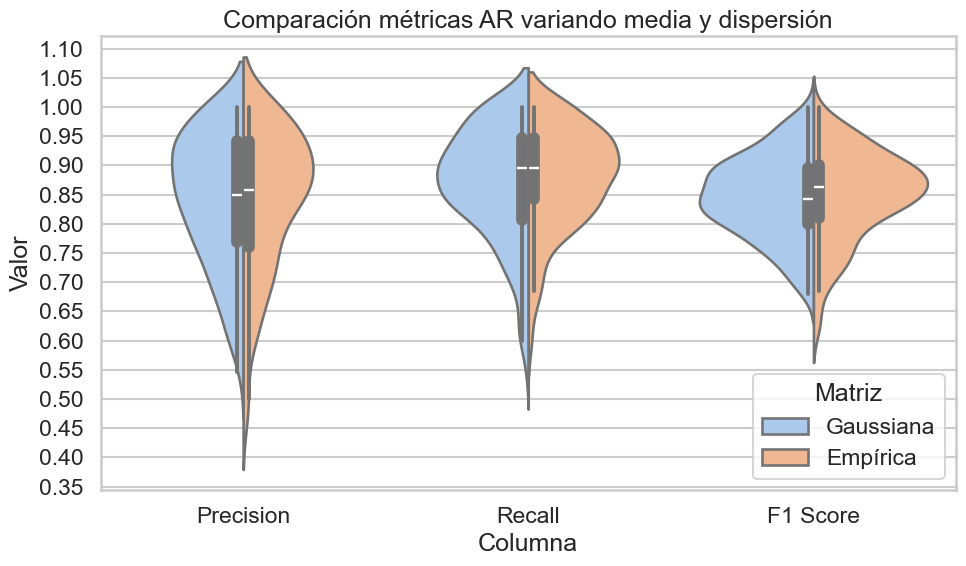

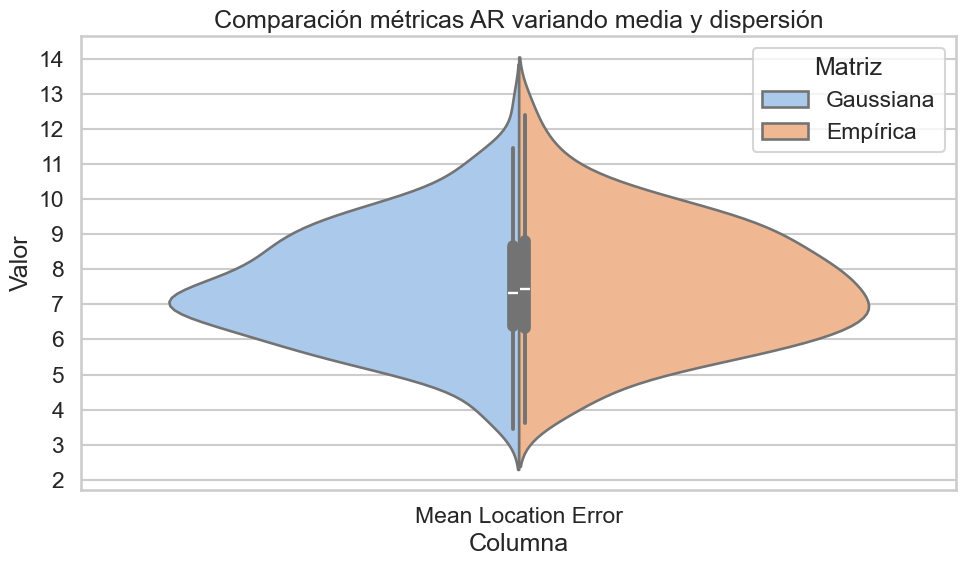

EXPERIMENTO AR(2) CON REZAGOS FLUCTUANTES
Media F1 Gaussiana: 0.8381927912780646
Media F1 Empírica: 0.8261498122741535

COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)
╒═════════════════════════════╤══════════════════════╤═════════════════════╤═══════════╤══════════════════════════╤════════════════╕
│ Métrica                     │   Promedio Gaussiano │   Promedio Empírico │   p-valor │ Diferencia estadística   │ Mejor método   │
╞═════════════════════════════╪══════════════════════╪═════════════════════╪═══════════╪══════════════════════════╪════════════════╡
│ Error Medio de Localización │             6.870331 │            7.008274 │  0.201582 │ No                       │ Sin diferencia │
├─────────────────────────────┼──────────────────────┼─────────────────────┼───────────┼──────────────────────────┼────────────────┤
│ Precisión                   │             0.854006 │            0.868271 │  0.089555 │ No                       │ Sin diferencia │
├────────────────────────

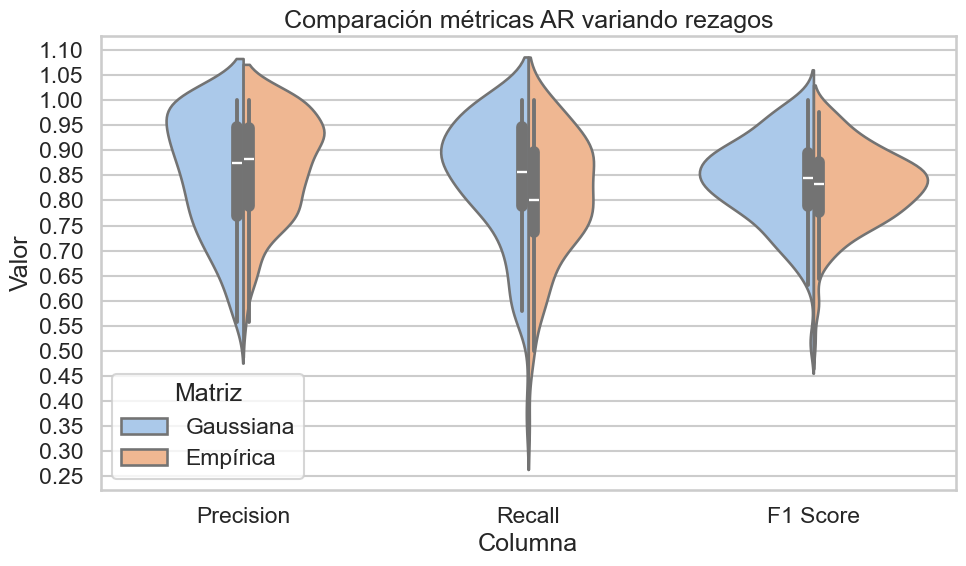

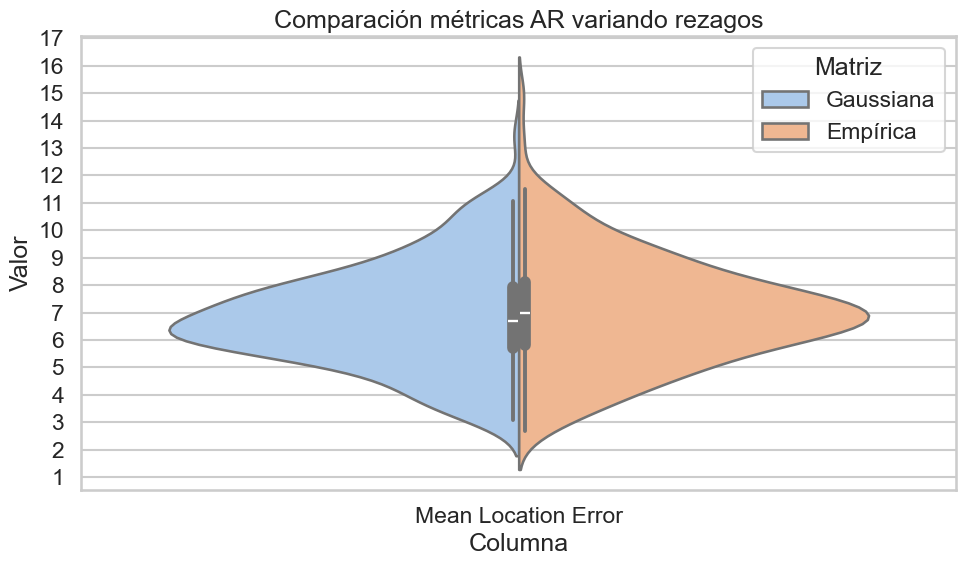

In [10]:
generar_resumen(data)

## 6. Resultados ECG200

In [7]:
from scipy.io import loadmat


ecg200 = loadmat("Series_Prueba/ECG200.mat")


In [23]:
cps_ecg = np.where(np.diff(ecg200['L'][0]) != 0)[0]
data_ecg = ecg200['Y'].reshape(-1)


In [15]:
met_ecg_gauss = best_params_sh(
            data_ecg,
            cps_ecg,
            penal=True,
            lambda_p=0,
            given=False,
            geom=True,
            visualization={
                "summary": False,
                "raw_distance": False,
                "smooth_distance": False,
                "cost": False,
                "slope": False
            },
            thr_dist=50,
            min_w=80,
            max_w=400,
)


════════════════════════════════════════════════════════════════════════
                         Optimización Gaussiano                         
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 8600
    Penalización                : Sí
    Codo dado                   : No
    Codo geométrico             : Sí

Detección de codo
─────────────────
    Método                      : Geométrico
    Punto umbral                : 56.0000

Selección final
───────────────
    Ventana óptima              : 120
    Retardo óptimo              : 1
    Beta                        : 0.0008
    [OK] Optimización finalizada


In [17]:
met_ecg_gauss

({'Mean Location Error': np.float64(26.818181818181817),
  'Precision': 0.4230769230769231,
  'Recall': 0.6111111111111112,
  'F1 Score': 0.5,
  'Accuracy': 0.9948837209302326,
  'Falsos Positivos': 30,
  'Falsos Negativos': 14,
  'Verdaderos Positivos': 22},
 {np.int64(2187): np.int64(2177),
  np.int64(3627): np.int64(3638),
  np.int64(7947): np.int64(7959),
  np.int64(3915): np.int64(3928),
  np.int64(4107): np.int64(4094),
  np.int64(5067): np.int64(5081),
  np.int64(6411): np.int64(6425),
  np.int64(8139): np.int64(8154),
  np.int64(843): np.int64(859),
  np.int64(5451): np.int64(5470),
  np.int64(5355): np.int64(5324),
  np.int64(1227): np.int64(1195),
  np.int64(2859): np.int64(2892),
  np.int64(4875): np.int64(4909),
  np.int64(4203): np.int64(4238),
  np.int64(5739): np.int64(5775),
  np.int64(1419): np.int64(1456),
  np.int64(267): np.int64(307),
  np.int64(6507): np.int64(6548),
  np.int64(8235): np.int64(8277),
  np.int64(4587): np.int64(4631),
  np.int64(8427): np.int64(847

In [19]:
met_ecg_emp = best_params_sh(
            data_ecg,
            cps_ecg,
            penal=True,
            lambda_p=0,
            given=False,
            geom=True,
            modo='Empírico',
            visualization={
                "summary": False,
                "raw_distance": False,
                "smooth_distance": False,
                "cost": False,
                "slope": False
            },
            thr_dist=50,
            min_w=80,
            max_w=400,
)


════════════════════════════════════════════════════════════════════════
                         Optimización Empírico                          
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 8600
    Penalización                : Sí
    Codo dado                   : No
    Codo geométrico             : Sí

 EmpiricalCPD :: Exhaustive Window Optimization
 Serie length                : 8600
 Window search interval      : [80, 400]
 Penalized optimization      : True
 Gaussian smoothing enabled  : True
 Parallel workers            : 15
 Total candidate windows     : 321
----------------------------------------------------------------------
[BEST UPDATE] w=400  | cost=3.381713 | cp=13
[BEST UPDATE] w=80   | cost=3.237117 | cp=62
[BEST UPDATE] w=81   | cost=3.236383 | cp=62
[BEST UPDATE] w=82   | cost=3.228405 | cp=64
[PROGRESS] 32/321 (10.0%)
[PROGRESS] 64/321 (19.9%)
[PROGRESS] 96/321 (29.9%)
[PROGRESS] 128/321 (39.9%)
[PROGRE

In [24]:
met_ecg_emp

({'Mean Location Error': np.float64(31.75),
  'Precision': 0.3076923076923077,
  'Recall': 0.1111111111111111,
  'F1 Score': 0.163265306122449,
  'Accuracy': 0.9952325581395349,
  'Falsos Positivos': 9,
  'Falsos Negativos': 32,
  'Verdaderos Positivos': 4},
 {np.int64(8139): np.int64(8138),
  np.int64(2187): np.int64(2147),
  np.int64(1707): np.int64(1749),
  np.int64(3819): np.int64(3863)})

In [27]:
from Algoritmo_Empiricas.Empirical_CPD import EmpiricalCPD
from Utils.detection import detect
from Utils.metrics_sup import metrics

algoritmo_emp = EmpiricalCPD(data_ecg, window=100)
distancias_emp = algoritmo_emp.distancias()

pc_detectados_emp_fixed = detect(
    distancias_emp,
    window=100,
    emp=True
    )

metricas_emp_fixed = metrics(cps_ecg, pc_detectados_emp_fixed, threshold=50, T=len(data_ecg))

In [28]:
metricas_emp_fixed

({'Mean Location Error': np.float64(31.285714285714285),
  'Precision': 1.0,
  'Recall': 0.19662921348314608,
  'F1 Score': 0.3286384976525822,
  'Accuracy': 0.9833720930232558,
  'Falsos Positivos': 0,
  'Falsos Negativos': 143,
  'Verdaderos Positivos': 35},
 {np.int64(2572): np.int64(2595),
  np.int64(5740): np.int64(5763),
  np.int64(1324): np.int64(1348),
  np.int64(2187): np.int64(2163),
  np.int64(2764): np.int64(2788),
  np.int64(3724): np.int64(3748),
  np.int64(1612): np.int64(1637),
  np.int64(1804): np.int64(1829),
  np.int64(7276): np.int64(7301),
  np.int64(7756): np.int64(7781),
  np.int64(171): np.int64(145),
  np.int64(6796): np.int64(6822),
  np.int64(5356): np.int64(5383),
  np.int64(3820): np.int64(3849),
  np.int64(652): np.int64(682),
  np.int64(4107): np.int64(4077),
  np.int64(2956): np.int64(2987),
  np.int64(7564): np.int64(7595),
  np.int64(843): np.int64(811),
  np.int64(5452): np.int64(5484),
  np.int64(7179): np.int64(7147),
  np.int64(8140): np.int64(8172

In [ ]:
np.savez(
                "Resultados/metricas_ECG200.npz",
                Gauss=met_ecg_gauss
            )

# Experimentos

In [7]:
from Series_Prueba.experimentos import generar_experimento_ar1, generar_experimento_ar2, generar_experimento_senoidal

## Experimento 1

In [ ]:
metricas_gauss_ar1 = []
metricas_emp_ar1 = []

np.random.seed(1234)
for i in range(200):
    ar1, cps_ar1, segmentos_ar1 = generar_experimento_ar1(
        N=2000,
        n_segmentos=20,
        min_sep=20,
        max_sep=200
    )

    met_gauss_ar1 = best_params_sh(
                    ar1,
                    cps_ar1,
                    penal=True,
                    modo="Gaussiano",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    met_emp_ar1 = best_params_sh(
                    ar1,
                    cps_ar1,
                    penal=True,
                    modo="Empírico",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    metricas_gauss_ar1.append(met_gauss_ar1)
    metricas_emp_ar1.append(met_emp_ar1)


════════════════════════════════════════════════════════════════════════
                         Optimización Gaussiano                         
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

Selección final
───────────────
    Ventana óptima              : 99
    Retardo óptimo              : 7
    Beta                        : 0.0090
    [OK] Optimización finalizada

════════════════════════════════════════════════════════════════════════
                         Optimización Empírico                          
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

 EmpiricalCPD :: Exhaustive Window Optimization
 Serie length                : 

In [33]:
metricas_gauss_ar1_ = [list(dic1.values()) for dic1, dic2 in metricas_gauss_ar1]
metricas_emp_ar1_ = [list(dic1.values()) for dic1, dic2 in metricas_emp_ar1]

In [39]:
np.savez(
                "Experimentos/I/metricas_ar1.npz",
                Gauss=metricas_gauss_ar1_,
                Emp=metricas_emp_ar1_
            )

In [66]:
data_ar1 = np.load("Experimentos/I/metricas_ar1.npz")

generar_informe_general(data_ar1, "Gauss", "Emp", path_media="Experimentos/I/Resumen_AR1_Media.xlsx", path_metricas="Experimentos/I/metricas_AR1.xlsx")


Media F1 Gaussiana: 0.1653482034816972
Media F1 Empírica: 0.13089005836768808

COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)
╒═════════════════════════════╤══════════════════════╤═════════════════════╤═══════════╤══════════════════════════╤════════════════╕
│ Métrica                     │   Promedio Gaussiano │   Promedio Empírico │   p-valor │ Diferencia estadística   │ Mejor método   │
╞═════════════════════════════╪══════════════════════╪═════════════════════╪═══════════╪══════════════════════════╪════════════════╡
│ Error Medio de Localización │             9.928494 │           10.074339 │  0.962207 │ No                       │ Sin diferencia │
├─────────────────────────────┼──────────────────────┼─────────────────────┼───────────┼──────────────────────────┼────────────────┤
│ Precisión                   │             0.399580 │            0.313336 │  0.000207 │ Sí                       │ Gaussiano      │
├─────────────────────────────┼──────────────────────┼────────────

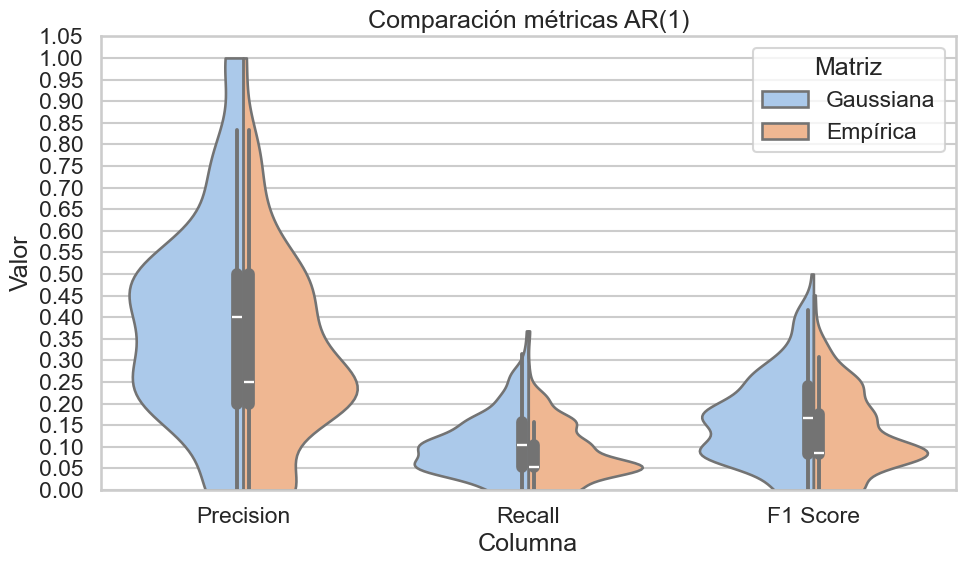

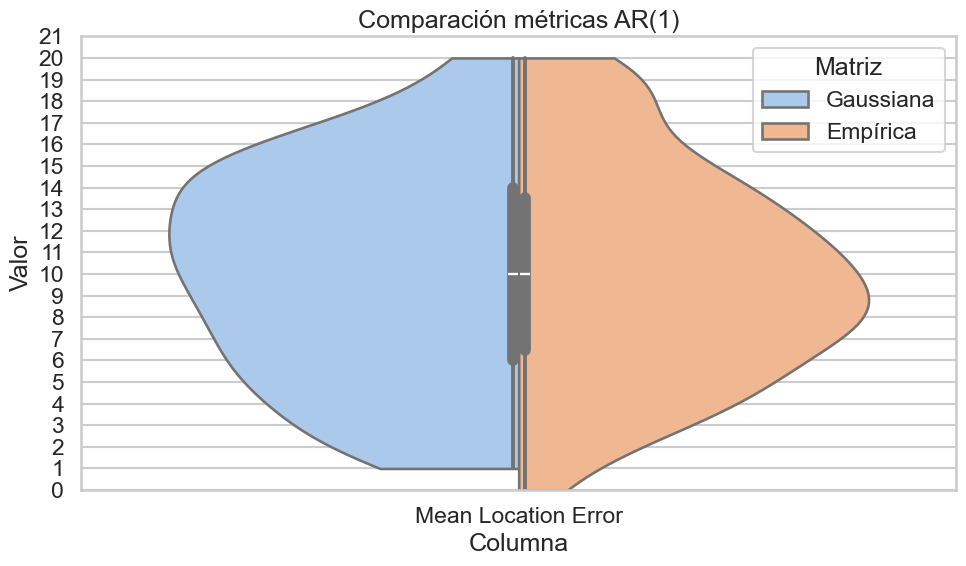

In [67]:
generar_resumen_general(data_ar1, 'Gauss', 'Emp', 
                        experimento="Comparación métricas AR(1)", 
                        path="Experimentos/I/Comparación_AR(1)")


## Experimento 2

In [ ]:
metricas_gauss_senoidal = []
metricas_emp_senoidal = []

np.random.seed(1234)
for i in range(200):
    print(f"Iteración {i+1}/200")
    senoidal, cps_senoidal, segmentos_senoidal = generar_experimento_senoidal(
        N=2000,
        n_segmentos=20,
        min_sep=20,
        max_sep=200, 
    )

    met_gauss_senoidal = best_params_sh(
                    senoidal,
                    cps_senoidal,
                    penal=True,
                    modo="Gaussiano",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    met_emp_senoidal = best_params_sh(
                    senoidal,
                    cps_senoidal,
                    penal=True,
                    modo="Empírico",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    metricas_gauss_senoidal.append(met_gauss_senoidal)
    metricas_emp_senoidal.append(met_emp_senoidal)

Iteración 1/200

════════════════════════════════════════════════════════════════════════
                         Optimización Gaussiano                         
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

Selección final
───────────────
    Ventana óptima              : 197
    Retardo óptimo              : 7
    Beta                        : 0.0035
    [OK] Optimización finalizada

════════════════════════════════════════════════════════════════════════
                         Optimización Empírico                          
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

 EmpiricalCPD :: Exhaustive Window Optimization
 Serie length 

In [68]:
metricas_gauss_senoidal_ = [list(dic1.values()) for dic1, dic2 in metricas_gauss_senoidal]
metricas_emp_senoidal_ = [list(dic1.values()) for dic1, dic2 in metricas_emp_senoidal]

In [72]:
np.savez(
                "Experimentos/II/metricas_senoidal.npz",
                Gauss=metricas_gauss_senoidal_,
                Emp=metricas_emp_senoidal_
            )

In [73]:
data_senoidal = np.load("Experimentos/II/metricas_senoidal.npz")

generar_informe_general(data_senoidal, "Gauss", "Emp", path_media="Experimentos/II/Resumen_Senoidal_Media.xlsx", path_metricas="Experimentos/II/metricas_Senoidal.xlsx")


Media F1 Gaussiana: 0.21925632057153796
Media F1 Empírica: 0.13592072002072

COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)
╒═════════════════════════════╤══════════════════════╤═════════════════════╤═══════════╤══════════════════════════╤════════════════╕
│ Métrica                     │   Promedio Gaussiano │   Promedio Empírico │   p-valor │ Diferencia estadística   │ Mejor método   │
╞═════════════════════════════╪══════════════════════╪═════════════════════╪═══════════╪══════════════════════════╪════════════════╡
│ Error Medio de Localización │             7.892801 │            9.368343 │  0.000807 │ Sí                       │ Gaussiano      │
├─────────────────────────────┼──────────────────────┼─────────────────────┼───────────┼──────────────────────────┼────────────────┤
│ Precisión                   │             0.694423 │            0.352613 │  0.000000 │ Sí                       │ Gaussiano      │
├─────────────────────────────┼──────────────────────┼──────────────

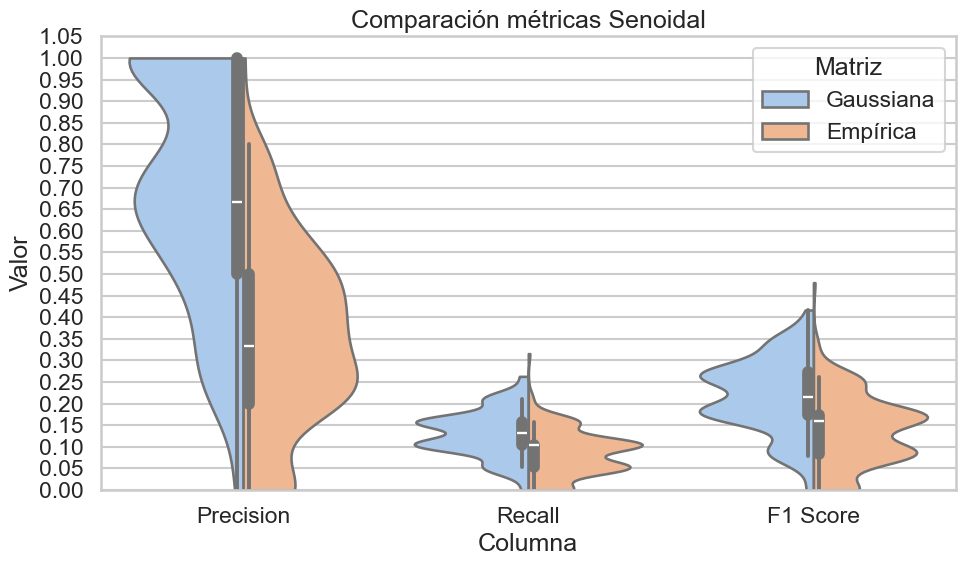

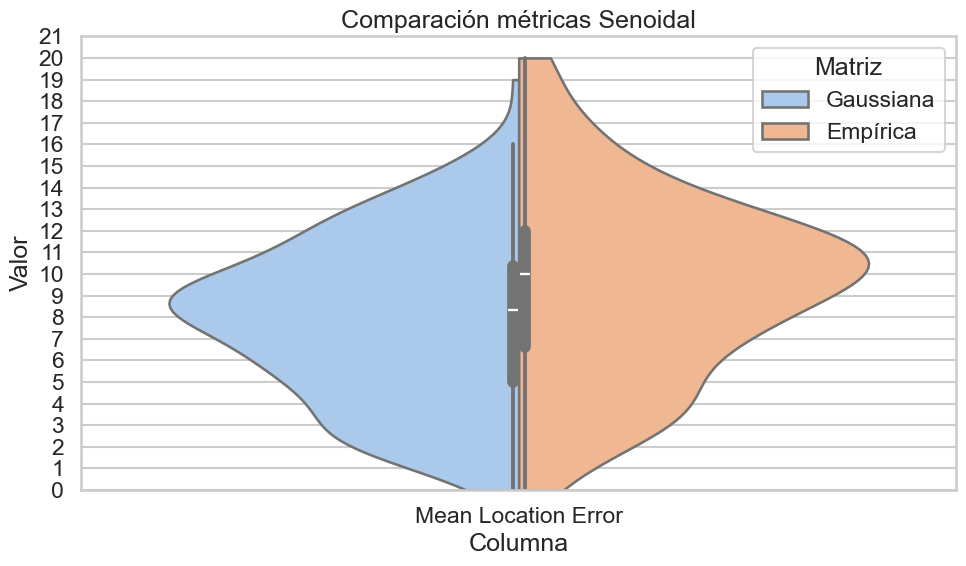

In [74]:
generar_resumen_general(data_senoidal, 'Gauss', 'Emp', 
                        experimento="Comparación métricas Senoidal", 
                        path="Experimentos/II/Comparación_Senoidal")


## Experimento 3

In [ ]:
metricas_gauss_ar2 = []
metricas_emp_ar2 = []

np.random.seed(1234)
for i in range(200):
    ar2, cps_ar2, segmentos_ar2 = generar_experimento_ar2(
        N=2000,
        n_segmentos=20,
        min_sep=20,
        max_sep=200
    )

    met_gauss_ar2 = best_params_sh(
                    ar2,
                    cps_ar2,
                    penal=True,
                    modo="Gaussiano",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    met_emp_ar2 = best_params_sh(
                    ar2,
                    cps_ar2,
                    penal=True,
                    modo="Empírico",
                    given=False,
                    geom=True,
                    thr_dist=20
                )

    metricas_gauss_ar2.append(met_gauss_ar2)
    metricas_emp_ar2.append(met_emp_ar2)


════════════════════════════════════════════════════════════════════════
                         Optimización Gaussiano                         
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

Selección final
───────────────
    Ventana óptima              : 191
    Retardo óptimo              : 10
    Beta                        : 0.0039
    [OK] Optimización finalizada

════════════════════════════════════════════════════════════════════════
                         Optimización Empírico                          
════════════════════════════════════════════════════════════════════════
    Tamaño de serie             : 2000
    Penalización                : Sí
    Codo dado                   : Sí
    Codo geométrico             : Sí

 EmpiricalCPD :: Exhaustive Window Optimization
 Serie length                

In [75]:
metricas_gauss_ar2_ = [list(dic1.values()) for dic1, dic2 in metricas_gauss_ar2]
metricas_emp_ar2_ = [list(dic1.values()) for dic1, dic2 in metricas_emp_ar2]

In [76]:
np.savez(
                "Experimentos/III/metricas_ar2.npz",
                Gauss=metricas_gauss_ar2_,
                Emp=metricas_emp_ar2_
            )

In [78]:
data_ar2 = np.load("Experimentos/III/metricas_ar2.npz")

generar_informe_general(data_ar2, "Gauss", "Emp", path_media="Experimentos/III/Resumen_AR2_Media.xlsx", path_metricas="Experimentos/III/metricas_AR2.xlsx")


Media F1 Gaussiana: 0.16456088756169038
Media F1 Empírica: 0.15130323274988602

COMPARACIÓN ESTADÍSTICA ENTRE MÉTODOS (WILCOXON PAREADO)
╒═════════════════════════════╤══════════════════════╤═════════════════════╤═══════════╤══════════════════════════╤════════════════╕
│ Métrica                     │   Promedio Gaussiano │   Promedio Empírico │   p-valor │ Diferencia estadística   │ Mejor método   │
╞═════════════════════════════╪══════════════════════╪═════════════════════╪═══════════╪══════════════════════════╪════════════════╡
│ Error Medio de Localización │             9.804514 │           10.270757 │  0.251842 │ No                       │ Sin diferencia │
├─────────────────────────────┼──────────────────────┼─────────────────────┼───────────┼──────────────────────────┼────────────────┤
│ Precisión                   │             0.361522 │            0.352276 │  0.660182 │ No                       │ Sin diferencia │
├─────────────────────────────┼──────────────────────┼───────────

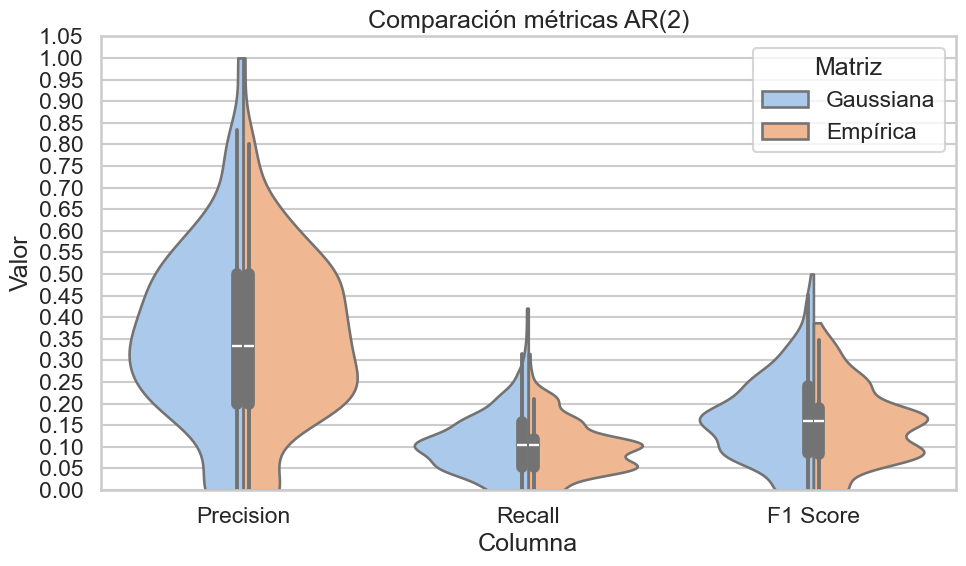

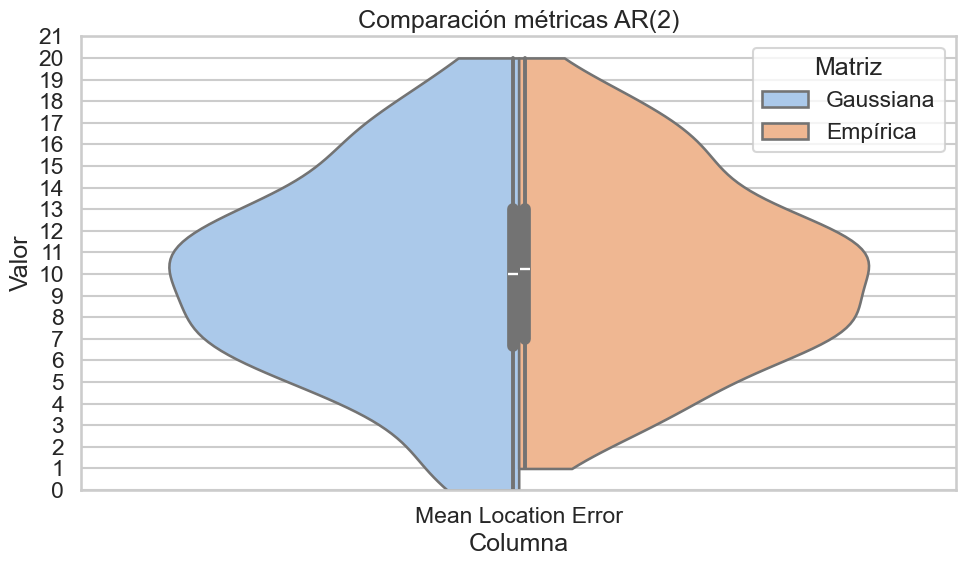

In [81]:
generar_resumen_general(data_ar2, 'Gauss', 'Emp', 
                        experimento="Comparación métricas AR(2)", 
                        path="Experimentos/III/Comparación_AR(2)")
